In [1]:
import datetime
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data(battery):
  mat = loadmat('/content/' + battery + '.mat')
  print('Total data in dataset: ', len(mat[battery][0, 0]['cycle'][0]))
  counter = 0
  dataset = []
  capacity_data = []

  for i in range(len(mat[battery][0, 0]['cycle'][0])):
    row = mat[battery][0, 0]['cycle'][0, i]
    if row['type'][0] == 'discharge':
      ambient_temperature = row['ambient_temperature'][0][0]
      date_time = datetime.datetime(int(row['time'][0][0]),
                               int(row['time'][0][1]),
                               int(row['time'][0][2]),
                               int(row['time'][0][3]),
                               int(row['time'][0][4])) + datetime.timedelta(seconds=int(row['time'][0][5]))
      data = row['data']
      capacity = data[0][0]['Capacity'][0][0]
      for j in range(len(data[0][0]['Voltage_measured'][0])):
        voltage_measured = data[0][0]['Voltage_measured'][0][j]
        current_measured = data[0][0]['Current_measured'][0][j]
        temperature_measured = data[0][0]['Temperature_measured'][0][j]
        current_load = data[0][0]['Current_load'][0][j]
        voltage_load = data[0][0]['Voltage_load'][0][j]
        time = data[0][0]['Time'][0][j]
        dataset.append([counter + 1, ambient_temperature, date_time, capacity,
                        voltage_measured, current_measured,
                        temperature_measured, current_load,
                        voltage_load, time])
      capacity_data.append([counter + 1, ambient_temperature, date_time, capacity])
      counter = counter + 1
  print(dataset[0])
  return [pd.DataFrame(data=dataset,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity', 'voltage_measured',
                                'current_measured', 'temperature_measured',
                                'current_load', 'voltage_load', 'time']),
          pd.DataFrame(data=capacity_data,
                       columns=['cycle', 'ambient_temperature', 'datetime',
                                'capacity'])]

In [3]:
dataset, capacity = load_data('B0005')
pd.set_option('display.max_columns', 10)
print(dataset.head())
dataset.describe()

Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.8564874208181574, 4.191491807505295, -0.004901589207462691, 24.330033885570543, -0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-04-02 15:25:41  1.856487          4.191492   
1      1                   24 2008-04-02 15:25:41  1.856487          4.190749   
2      1                   24 2008-04-02 15:25:41  1.856487          3.974871   
3      1                   24 2008-04-02 15:25:41  1.856487          3.951717   
4      1                   24 2008-04-02 15:25:41  1.856487          3.934352   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.004902             24.330034       -0.0006         0.000   0.000  
1         -0.001478             24.325993       -0.0006         4.206  16.781  
2         -2.012528             24.389085       -1.9982         3.062  35.703  
3         -2.

,cycle,ambient_temperature,capacity,voltage_measured,current_measured,temperature_measured,current_load,voltage_load,time
count,50285.000000,50285.0,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000,50285.000000
mean,88.125942,24.0,1.560345,3.515268,-1.806032,32.816991,1.362700,2.308406,1546.208924
std,45.699687,0.0,0.182380,0.231778,0.610502,3.987515,1.313698,0.800300,906.640295
min,1.000000,24.0,1.287453,2.455679,-2.029098,23.214802,-1.998400,0.000000,0.000000
25%,50.000000,24.0,1.386229,3.399384,-2.013415,30.019392,1.998000,2.388000,768.563000
50%,88.000000,24.0,1.538237,3.511664,-2.012312,32.828944,1.998200,2.533000,1537.031000
75%,127.000000,24.0,1.746871,3.660903,-2.011052,35.920887,1.998200,2.690000,2305.984000
max,168.000000,24.0,1.856487,4.222920,0.007496,41.450232,1.998400,4.238000,3690.234000


In [4]:
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity'])/C
print(dis_ele)

C = dataset['capacity'][0]
soh = []
for i in range(len(dataset)):
  soh.append([dataset['capacity'][i] / C])
soh = pd.DataFrame(data=soh, columns=['SoH'])

attribs=['capacity', 'voltage_measured', 'current_measured',
         'temperature_measured', 'current_load', 'voltage_load', 'time']
train_dataset = dataset[attribs]
sc = MinMaxScaler(feature_range=(0,1))
train_dataset = sc.fit_transform(train_dataset)
print(train_dataset.shape)
print(soh.shape)

     cycle            datetime  capacity       SoH
0        1 2008-04-02 15:25:41  1.856487  1.000000
1        2 2008-04-02 19:43:48  1.846327  0.994527
2        3 2008-04-03 00:01:06  1.835349  0.988614
3        4 2008-04-03 04:16:37  1.835263  0.988567
4        5 2008-04-03 08:33:25  1.834646  0.988235
..     ...                 ...       ...       ...
163    164 2008-05-26 10:44:38  1.293464  0.696726
164    165 2008-05-26 15:30:43  1.288003  0.693785
165    166 2008-05-26 20:21:04  1.287453  0.693488
166    167 2008-05-27 15:52:41  1.309015  0.705103
167    168 2008-05-27 20:45:42  1.325079  0.713756

[168 rows x 4 columns]
(50285, 7)
(50285, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam

regress = Sequential()
regress.add(Bidirectional(LSTM(units=200), input_shape=(train_dataset.shape[1], 1)))
regress.add(Dropout(0.3))
regress.add(Dense(units=1))
regress.compile(optimizer='adam', loss='mean_squared_error')
regress.summary()

regress.fit(x=train_dataset, y=soh.to_numpy(), batch_size=20, epochs=30)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 400)               323200    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 1)                 401       
                                                                 
Total params: 323601 (1.23 MB)
Trainable params: 323601 (1.23 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/30
2515/2515 [==============================] - 73s 26ms/step - loss: 0.0027
Epoch 2/30
2515/2515 [==============================] - 66s 26ms/step - loss: 6.8221e-04
Epoch 3/30
2515/2515 [======================

In [ ]:
# Sauvegarder le modèle
regress.save('ModeleLSTMB0005.h5')
regress.save('ModeleLSTMB0005versionKeras.keras')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING
Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 2.035337591005598, 4.179799607333447, -0.0023663271409738672, 24.277567510331888, -0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-04-02 15:25:41  2.035338          4.179800   
1      1                   24 2008-04-02 15:25:41  2.035338          4.179823   
2      1                   24 2008-04-02 15:25:41  2.035338          3.966528   
3      1                   24 2008-04-02 15:25:41  2.035338          3.945886   
4      1                   24 2008-04-02 15:25:41  2.035338          3.930354   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.002366             24.277568       -0.0006         0.000   0.000  
1          0.000434             24.277073       -0.0006         4.195  16.781  
2         -2.014242             24.

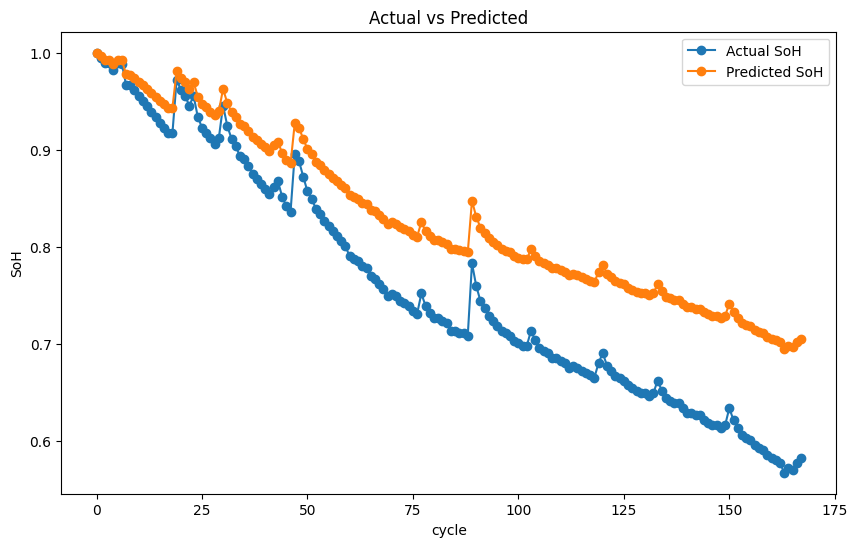

In [ ]:
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING")
dataset_val, capacity_val = load_data('B0006')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred = regress.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.ACTUAL AND PREDICTED SOH")
C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((new_soh['SoH'] - new_soh['NewSoH']) / new_soh['SoH'])) * 100
print("Mean Absolute Percentage Error (MAPE):", mape)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(new_soh['SoH'], new_soh['NewSoH'])
print("Mean Squared Error (MSE):", mse)
mae = mean_absolute_error(new_soh['SoH'], new_soh['NewSoH'])
print(f'Mean Absolute Error (MAE): {mae:.4f}')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
plt.plot(new_soh['SoH'], label='Actual SoH', marker='o')
plt.plot(new_soh['NewSoH'], label='Predicted SoH', marker='o')
plt.title('Actual vs Predicted SoH - B0006')
plt.xlabel('cycle')
plt.ylabel('SoH')
plt.legend()
plt.title(f'Actual vs Predicted')
plt.show()

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING
Total data in dataset:  616
[1, 24, datetime.datetime(2008, 4, 2, 15, 25, 41), 1.89105229539079, 4.199359521791473, -0.0018658918833680202, 23.93704394613529, -0.0004, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-04-02 15:25:41  1.891052          4.199360   
1      1                   24 2008-04-02 15:25:41  1.891052          4.199497   
2      1                   24 2008-04-02 15:25:41  1.891052          3.985606   
3      1                   24 2008-04-02 15:25:41  1.891052          3.963247   
4      1                   24 2008-04-02 15:25:41  1.891052          3.946647   

   current_measured  temperature_measured  current_load  voltage_load    time  
0         -0.001866             23.937044       -0.0004         0.000   0.000  
1         -0.002139             23.924074       -0.0004         4.215  16.781  
2         -1.988778             24.00

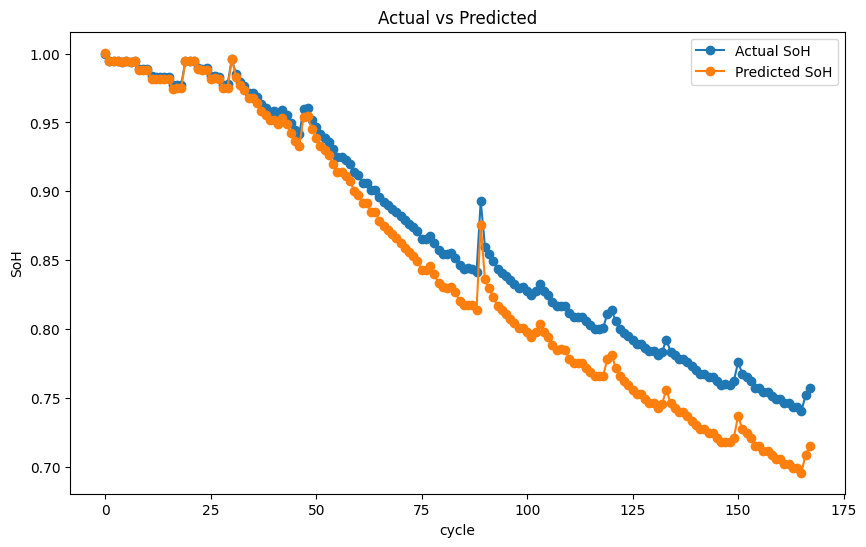

In [ ]:
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING")
dataset_val, capacity_val = load_data('B0007')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred = regress.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.ACTUAL AND PREDICTED SOH")
C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((new_soh['SoH'] - new_soh['NewSoH']) / new_soh['SoH'])) * 100
print("Mean Absolute Percentage Error (MAPE):", mape)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(new_soh['SoH'], new_soh['NewSoH'])
print("Mean Squared Error (MSE):", mse)
mae = mean_absolute_error(new_soh['SoH'], new_soh['NewSoH'])
print(f'Mean Absolute Error (MAE): {mae:.4f}')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
plt.plot(new_soh['SoH'], label='Actual SoH', marker='o')
plt.plot(new_soh['NewSoH'], label='Predicted SoH', marker='o')
plt.title('Actual vs Predicted SoH - B0007')
plt.xlabel('cycle')
plt.ylabel('SoH')
plt.legend()
plt.title(f'Actual vs Predicted')
plt.show()

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING
Total data in dataset:  319
[1, 24, datetime.datetime(2008, 7, 7, 15, 15, 28), 1.8550045207910817, 4.188108651124536, 0.00013066734156636677, 23.8195202516044, 0.0006, 0.0, 0.0]
   cycle  ambient_temperature            datetime  capacity  voltage_measured  \
0      1                   24 2008-07-07 15:15:28  1.855005          4.188109   
1      1                   24 2008-07-07 15:15:28  1.855005          4.188196   
2      1                   24 2008-07-07 15:15:28  1.855005          3.977432   
3      1                   24 2008-07-07 15:15:28  1.855005          3.961974   
4      1                   24 2008-07-07 15:15:28  1.855005          3.949835   

   current_measured  temperature_measured  current_load  voltage_load    time  
0          0.000131             23.819520        0.0006         0.000   0.000  
1          0.001459             23.828807        0.0006         4.203   9.422  
2         -2.005672             23.84

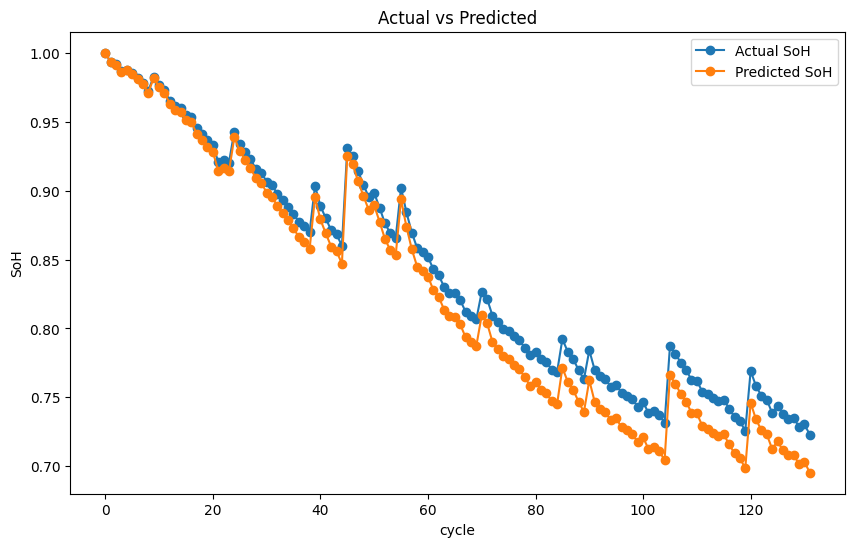

In [ ]:
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> TESTING")
dataset_val, capacity_val = load_data('B0018')
attrib=['cycle', 'datetime', 'capacity']
dis_ele = capacity_val[attrib]
C = dis_ele['capacity'][0]
for i in range(len(dis_ele)):
    dis_ele['SoH']=(dis_ele['capacity']) / C
print(dataset_val.head(5))
print(dis_ele.head(5))
attrib=['capacity', 'voltage_measured', 'current_measured',
        'temperature_measured', 'current_load', 'voltage_load', 'time']
soh_pred = regress.predict(sc.fit_transform(dataset_val[attrib]))
print(soh_pred.shape)
print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>.ACTUAL AND PREDICTED SOH")
C = dataset_val['capacity'][0]
soh = []
for i in range(len(dataset_val)):
  soh.append(dataset_val['capacity'][i] / C)
new_soh = dataset_val.loc[(dataset_val['cycle'] >= 1), ['cycle']]
new_soh['SoH'] =  soh
new_soh['NewSoH'] = soh_pred
new_soh = new_soh.groupby(['cycle']).mean().reset_index()
print(new_soh.head(10))
rms = np.sqrt(mean_squared_error(new_soh['SoH'], new_soh['NewSoH']))
print('Root Mean Square Error: ', rms)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((new_soh['SoH'] - new_soh['NewSoH']) / new_soh['SoH'])) * 100
print("Mean Absolute Percentage Error (MAPE):", mape)
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(new_soh['SoH'], new_soh['NewSoH'])
print("Mean Squared Error (MSE):", mse)
mae = mean_absolute_error(new_soh['SoH'], new_soh['NewSoH'])
print(f'Mean Absolute Error (MAE): {mae:.4f}')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Tracer les valeurs réelles vs les valeurs prédites
plt.figure(figsize=(10, 6))
plt.plot(new_soh['SoH'], label='Actual SoH', marker='o')
plt.plot(new_soh['NewSoH'], label='Predicted SoH', marker='o')
plt.title('Actual vs Predicted SoH - B0018')
plt.xlabel('cycle')
plt.ylabel('SoH')
plt.legend()
plt.title(f'Actual vs Predicted')
plt.show()